<a href="https://colab.research.google.com/github/celinekm/CN/blob/main/atv2_celine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nome: Celine Kazumi Miyajima RA: 176209**

IMPLEMENTAÇÃO DO CÓDIGO

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


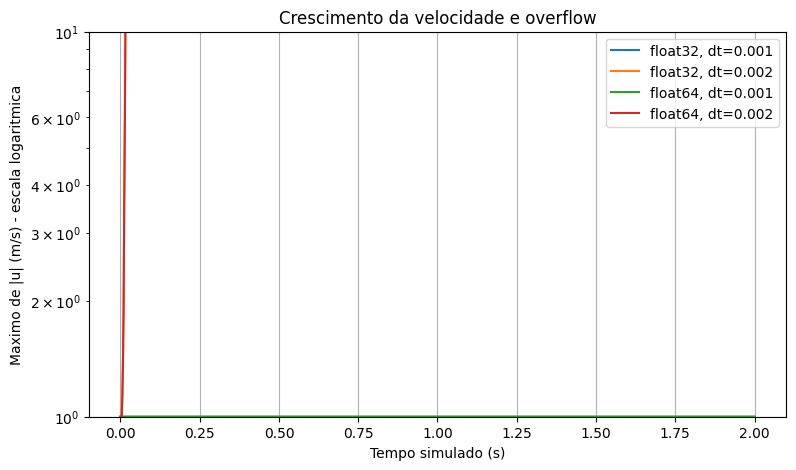

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)
    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)
    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)
    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None
    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r
                    * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))
    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )
    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)
resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

**1 - VERIFICAÇÃO DA ESTABILIDADE**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 120,
})

H = 0.01
nu = 1e-4
U = 1.0
pontos = 21

dy = H / (pontos - 1)
dt_max = dy**2 / (2 * nu)

print(f"Δy = {dy:.7f} m")
print(f"Δt_max = {dt_max:.7f} s")


Δy = 0.0005000 m
Δt_max = 0.0012500 s


In [4]:
casos = [("Caso A", 0.001), ("Caso B", 0.002)]

linhas = []
for caso, dt in casos:
    r = nu * dt / dy**2
    linhas.append([caso, dt, r, "Estável" if r <= 0.5 else "Instável"])

tabela_estabilidade = pd.DataFrame(
    linhas, columns=["Caso", "Δt (s)", "r", "Classificação"]
)
tabela_estabilidade


,Caso,Δt (s),r,Classificação
0,Caso A,0.001,0.4,Estável
1,Caso B,0.002,0.8,Instável


**2 - DETECÇÃO DO OVERFLOW**

In [6]:
resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo, passos=2000, pontos=21)

linhas = []
for resultado in resultados.values():
    linhas.append({
        "Tipo numérico": resultado["tipo"],
        "Δt (s)": resultado["dt"],
        "r": resultado["r"],
        "Overflow": "Sim" if resultado["falha"] is not None else "Não",
        "Passo da falha": resultado["falha"] if resultado["falha"] else "—",
        "Passos executados": len(resultado["tempos"]) - 1,
        "Máximo |u| (m/s)": np.max(resultado["maximos"])
    })

tabela_testes = pd.DataFrame(linhas)
tabela_testes


/usr/local/lib/python3.13/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,Tipo numérico,Δt (s),r,Overflow,Passo da falha,Passos executados,Máximo |u| (m/s)
0,float32,0.001,0.4,Não,—,2000,1.000000e+00
1,float32,0.002,0.8,Sim,121,120,1.665934e+38
2,float64,0.001,0.4,Não,—,2000,1.000000e+00
3,float64,0.002,0.8,Sim,917,916,4.743391e+307


**3 - INTERPRETAÇÃO FÍSICA**

O crescimento observado no caso instável não representa o comportamento físico esperado porque o passo de tempo viola a condição de estabilidade do método. Erros e perturbações são amplificados a cada iteração, produzindo velocidades não físicas e podendo levar posteriormente ao overflow.

**4 - CAPACIDADE DE REPRESENTAÇÃO**

A mudança de `float32` para `float64` não elimina a instabilidade. Ela aumenta a faixa de representação, podendo atrasar o overflow, mas a condição de estabilidade continua sendo r ≤ 1/2. Portanto, a causa da falha é o passo de tempo excessivo.

**5 - REFINAMENTO DE MALHA**

In [8]:
pontos_refinada = 41
dy_41 = H / (pontos_refinada - 1)
dt_max_41 = dy_41**2 / (2 * nu)

print(f"Novo Δy = {dy_41:.8f} m")
print(f"Novo Δt_max = {dt_max_41:.8f} s")

resultado_41_dt001 = simular(0.001, np.float64, 2000, 41)

print(f"r para Δt=0,001 s: {resultado_41_dt001['r']:.4f}")
print("Classificação:", "Estável" if resultado_41_dt001["r"] <= 0.5 else "Instável")


Novo Δy = 0.00025000 m
Novo Δt_max = 0.00031250 s
r para Δt=0,001 s: 1.6000
Classificação: Instável


In [9]:
dt_seguro_41 = dt_max_41 / 2

resultado_41_seguro = simular(
    dt_seguro_41, np.float64, 2000, 41
)

print(f"Δt seguro = {dt_seguro_41:.8f} s")
print(f"r = {resultado_41_seguro['r']:.4f}")
print("Overflow:", "Sim" if resultado_41_seguro["falha"] else "Não")


Δt seguro = 0.00015625 s
r = 0.2500
Overflow: Não


In [10]:
comparacao_malha = pd.DataFrame([
    ["21 pontos", dy, dt_max, 0.001, 0.4, "Estável"],
    ["21 pontos", dy, dt_max, 0.002, 0.8, "Instável"],
    ["41 pontos", dy_41, dt_max_41, 0.001, resultado_41_dt001["r"], "Instável"],
    ["41 pontos", dy_41, dt_max_41, dt_seguro_41, resultado_41_seguro["r"], "Estável"],
], columns=["Malha", "Δy (m)", "Δt_max (s)", "Δt utilizado (s)", "r", "Classificação"])

comparacao_malha


,Malha,Δy (m),Δt_max (s),Δt utilizado (s),r,Classificação
0,21 pontos,0.00050,0.001250,0.001000,0.40,Estável
1,21 pontos,0.00050,0.001250,0.002000,0.80,Instável
2,41 pontos,0.00025,0.000312,0.001000,1.60,Instável
3,41 pontos,0.00025,0.000312,0.000156,0.25,Estável


Ao aumentar o número de pontos, Δy diminui. Como Δt_max é proporcional a Δy², o limite temporal também diminui. Por isso, Δt = 0,001 s, que era estável com 21 pontos, torna-se instável com 41 pontos. A correção é reduzir Δt para um valor abaixo do novo limite.

**6 - VERIFICAÇÃO DO PERFIL DE VELOCIDADE**

In [11]:
dt_perfil = 0.001
passos_perfil = 10000

resultado_perfil = simular(
    dt_perfil, np.float64, passos_perfil, 21
)

y_perfil = resultado_perfil["y"]
u_numerica = resultado_perfil["u"]
u_est = U * (1 - y_perfil / H)

erro_inf = np.max(np.abs(u_numerica - u_est))

print(f"Tempo total = {passos_perfil * dt_perfil:.3f} s")
print(f"Erro máximo E∞ = {erro_inf:.6e} m/s")


Tempo total = 10.000 s
Erro máximo E∞ = 3.441691e-15 m/s


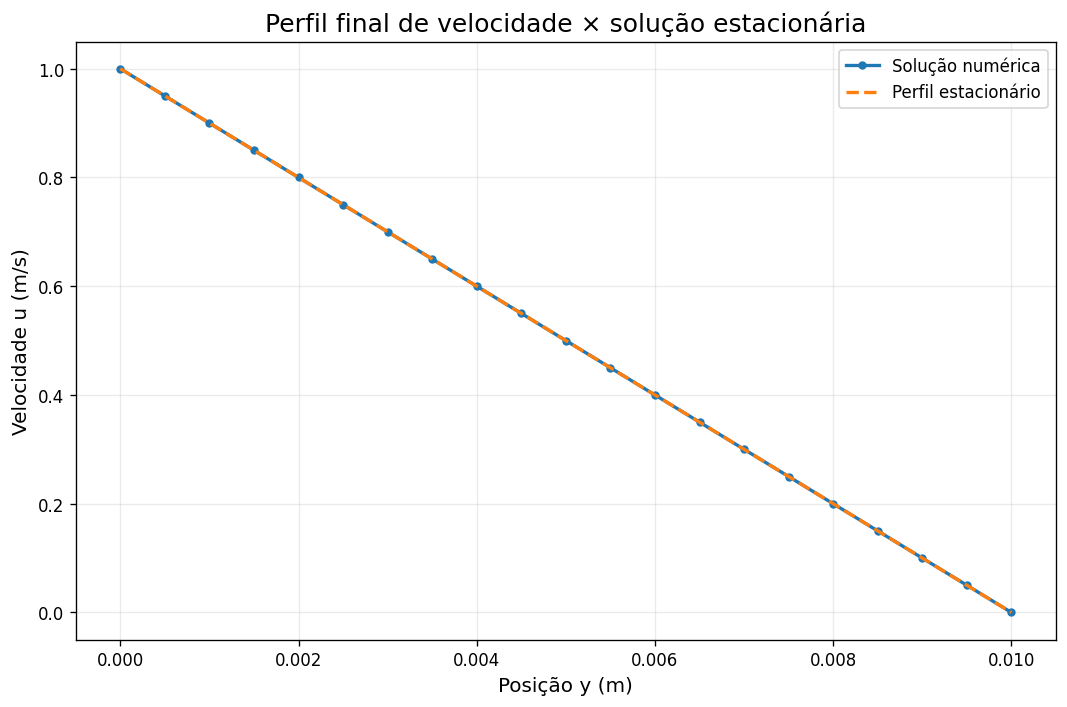

In [12]:
plt.figure(figsize=(9, 6))

plt.plot(
    y_perfil, u_numerica,
    marker="o", markersize=4, linewidth=2,
    label="Solução numérica"
)
plt.plot(
    y_perfil, u_est,
    linestyle="--", linewidth=2,
    label="Perfil estacionário"
)

plt.xlabel("Posição y (m)")
plt.ylabel("Velocidade u (m/s)")
plt.title("Perfil final de velocidade × solução estacionária")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


A solução numérica tende ao perfil estacionário à medida que o tempo aumenta. Como a simulação parte de um fluido inicialmente parado, existe um transiente. Portanto, a diferença medida pelo erro E∞ pode incluir o fato de o regime permanente ainda não ter sido completamente atingido.

**7 - CONCLUSÃO**

A atividade demonstrou que o refinamento da malha exige a redução do passo de tempo para manter a estabilidade numérica. Quando a condição r ≤ 5 foi violada, ocorreram instabilidades que posteriormente levaram ao overflow. O uso de `float64` apenas adiou a ocorrência do overflow, sem eliminar a instabilidade. Assim, a forma correta de corrigir a falha foi reduzir o passo de tempo, mantendo o método dentro do limite de estabilidade.
